# Programming Assignment 1

Segmentação de instâncias com as arquiteturas da aula

Equipe: Jaime Willian Carneiro da Silva & Luiz Eduardo Bravin

In [67]:
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader, random_split, Dataset
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import time

Escolheremos a opção A - DSB2018 / BBBC038v1

Download:  https://bbbc.broadinstitute.org/BBBC038

In [68]:
def generate_image(img_size: int, seed: int = None):
    image = np.zeros((img_size, img_size, 3), dtype= np.uint8)
    rng = np.random.default_rng(seed=seed)
    num_ellipses = int(rng.integers(5, 21))
    instance_masks = np.zeros((num_ellipses, img_size, img_size), dtype= np.uint8)
    
    for idx in range(num_ellipses):
        center = tuple(rng.integers(0, img_size + 1, size=2).tolist())
        axes = tuple(rng.integers(5, 41, size=2).tolist())
        angle = int(rng.integers(0, 101))
        color = tuple(rng.integers(50, 256, size=3).tolist())
    
        cv.ellipse(image, center, axes, angle, 0, 360, color, -1)
        cv.ellipse(instance_masks[idx], center, axes, angle, 0, 360, 1, -1)
        
    contrast = rng.random() + 0.5
    noise = rng.integers(-20, 20, size=(img_size, img_size, 3))
    image = (image * contrast) + noise
    image = np.clip(image, 0 , 255 ).astype(np.uint8)

    return image, instance_masks

Classes

In [69]:
class SyntheticEllipseDataset(Dataset):
    def __init__(self, num_samples: int, img_size: int = 128) -> None:
        super().__init__()
        self.num_samples = num_samples
        self.img_size = img_size

    def __len__(self):
        return self.num_samples

    def __getitem__(self, _):
        image, instance_masks = generate_image(self.img_size)

        image = image.transpose((2, 0, 1))
        image_tensor = torch.from_numpy(image).float() / 255.0

        binary_np = (instance_masks.sum(axis=0) > 0).astype(np.float32)
        binary_mask_tensor = torch.from_numpy(binary_np).unsqueeze(0)

        instance_gt = np.zeros((self.img_size, self.img_size), dtype=np.int32)
        for i, mask_elipse in enumerate(instance_masks):
            instance_gt[mask_elipse > 0] = i + 1
            
        return image_tensor, binary_mask_tensor, instance_gt

class UNetBinary(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        
        # ENCODER
        self.enc1 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu) # 64x64
        self.pool = resnet.maxpool # 32x32
        self.enc2 = resnet.layer1  # 32x32, 64 canais
        self.enc3 = resnet.layer2  # 16x16, 128 canais
        self.enc4 = resnet.layer3  # 8x8, 256 canais

        # DECODER
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = nn.Sequential(nn.Conv2d(256, 128, kernel_size=3, padding=1), nn.ReLU())
        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = nn.Sequential(nn.Conv2d(128, 64, kernel_size=3, padding=1), nn.ReLU())
        self.up1 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)
        self.dec1 = nn.Sequential(nn.Conv2d(128, 64, kernel_size=3, padding=1), nn.ReLU())
        self.up0 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.final_conv = nn.Conv2d(32, 1, kernel_size=1) # Saída de 1 canal

    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.enc2(self.pool(x1))
        x3 = self.enc3(x2)
        x4 = self.enc4(x3)

        d3 = self.dec3(torch.cat([self.up3(x4), x3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), x2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), x1], dim=1))
        
        return self.final_conv(self.up0(d1))

Funções

In [70]:
def train_model(model, dataloader, device, lr=1e-3, num_epochs=5):
    model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    num_batchs = len(dataloader)

    for epoch in range(num_epochs):
        model.train()
        accumulated_loss = 0.0
        total_intersection = 0.0
        total_union = 0.0
        
        for images, masks, _ in dataloader:
            images = images.to(device)
            masks = masks.to(device)
            
            optimizer.zero_grad()
            prediction = model(images)
            loss = criterion(prediction, masks)
            loss.backward()
            optimizer.step()

            binary_prediction = (torch.sigmoid(prediction) > 0.5).float()
            intersection = (binary_prediction * masks).sum()
            union = binary_prediction.sum() + masks.sum() - intersection
            
            accumulated_loss += loss.item()
            total_intersection += intersection.item()
            total_union += union.item()

        epoch_iou = total_intersection / (total_union + 1e-6)
        epoch_dice = (2.0 * total_intersection) / (total_union + total_intersection + 1e-6)
        print(f"Epoch {epoch+1}/{num_epochs} | Loss: {accumulated_loss/num_batchs:.4f} | Semantic IoU: {epoch_iou:.4f} | Dice: {epoch_dice:.4f}")


def predict(model, dataloader, device):
    images, _, real_instances = next(iter(dataloader))
    model.eval()
    with torch.no_grad():
        binary_preds = (torch.sigmoid(model(images.to(device))) > 0.5).float().cpu().numpy()
        
    prediction_instances = np.zeros_like(binary_preds)
    for i in range(binary_preds.shape[0]):
        mask_i = binary_preds[i].squeeze().astype(np.uint8)
        prediction_instances[i, 0] = cv.connectedComponents(mask_i)[1]
        
    return images.numpy(), real_instances.numpy(), prediction_instances

Parte 0 - Teste Unitário

In [71]:
dataset = SyntheticEllipseDataset(num_samples=500, img_size=128)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)
model = UNetBinary()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

start = time.time()
train_model(model, dataloader, device)
print(f"Training time: {(time.time() - start) / 60:.2f} minutes")

Epoch 1/5 | Loss: 0.1499 | Semantic IoU: 0.8971 | Dice: 0.9457
Epoch 2/5 | Loss: 0.0244 | Semantic IoU: 0.9849 | Dice: 0.9924
Epoch 3/5 | Loss: 0.0110 | Semantic IoU: 0.9942 | Dice: 0.9971
Epoch 4/5 | Loss: 0.0059 | Semantic IoU: 0.9975 | Dice: 0.9987
Epoch 5/5 | Loss: 0.0034 | Semantic IoU: 0.9986 | Dice: 0.9993
Training time: 2.41 minutes


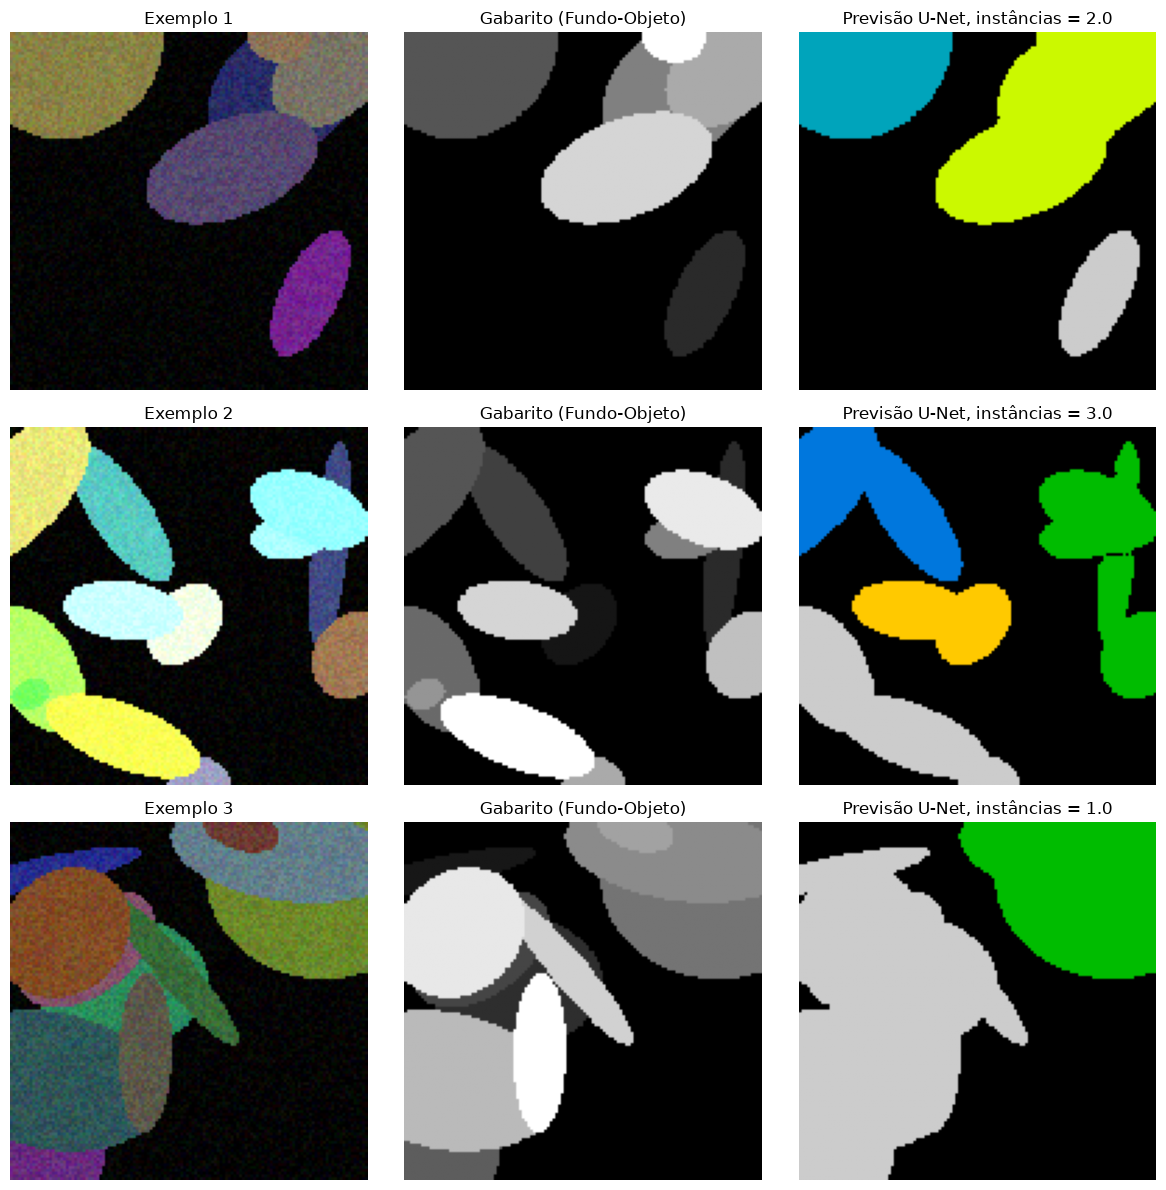

In [ ]:
images, real_masks, prediction_masks = predict(model, dataloader, device)

num_samples = 3
fig, axs = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))

for i in range(num_samples):
    # (Canais, Altura, Largura) -> (Altura, Largura, Canais)
    img_vis = images[i].transpose((1, 2, 0))
    
    mask_real_vis = real_masks[i]
    mask_prev_vis = prediction_masks[i][0]

    # Coluna 1: Imagem
    axs[i, 0].imshow(img_vis)
    axs[i, 0].set_title(f"Exemplo {i+1}")
    axs[i, 0].axis('off')

    # Coluna 2: Gabarito
    axs[i, 1].imshow(mask_real_vis, cmap='gray')
    axs[i, 1].set_title("Gabarito (Fundo-Objeto)")
    axs[i, 1].axis('off')

    # Coluna 3: Previsão U-Net
    axs[i, 2].imshow(mask_prev_vis, cmap='nipy_spectral')
    axs[i, 2].set_title(f"Previsão U-Net, instâncias = {np.max(mask_prev_vis) - 1}")
    axs[i, 2].axis('off')

plt.tight_layout()
plt.show()